# Fast Offline DQN Pipeline

This notebook builds a correct and fast data pipeline for offline DQN training on Box Moving.

The focus is on reducing Python overhead, keeping batch construction JAX-friendly, and running the training loop with `jax.lax.scan`.

In [1]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
from __future__ import annotations

from pathlib import Path
import sys
import time
from typing import Any

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import ml_collections
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "pyproject.toml").exists() else NOTEBOOK_DIR.parent
SRC_ROOT = REPO_ROOT / "src"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from config import Config, ExpConfig
from envs import create_env
from envs.block_moving.block_moving_env import BoxMovingEnv
from envs.block_moving.env_types import BoxMovingConfig, remove_targets
from envs.block_moving.input_features import encode_grid_inputs
from envs.block_moving.wrappers import wrap_for_eval
from impls.agents import create_agent, default_config
from impls.utils.checkpoints import save_agent
from train import collect_data

## Configure Paths and Reproducibility

Set the dataset path, output directory, random seed, and runtime settings up front so the notebook is deterministic and easy to rerun.

In [ ]:
DATASET_PATH = REPO_ROOT / "data" / "expert_default_6x6_3boxes_10000traj_parallel512_fixed100.npy"
OUTPUT_DIR = REPO_ROOT / "runs" / "fast_offline_dqn_pipeline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
BATCH_SIZE = 512
NUM_UPDATES = 200_000
NUM_EVAL_CHECKPOINTS = 5
LOG_EVERY = 100
EVAL_EVERY = 500
NUM_EVAL_ENVS = 512
INPUT_REPRESENTATION = "factored_flat"
USE_TARGETS = False
DISCOUNT = 0.99
# VALUE_P_CURGOAL = 0.2
# VALUE_P_TRAJGOAL = 0.5
# VALUE_P_RANDOMGOAL = 0.3
VALUE_P_CURGOAL = 0.0
VALUE_P_TRAJGOAL = 1.0
VALUE_P_RANDOMGOAL = 0.0
GRID_SIZE = 6
NUM_BOXES = 3
EP_LEN = 100
QUARTER_SIZE = 3
AGENT_NAME = "crl_search_cnn"

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"Dataset path: {DATASET_PATH}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Seed: {SEED}")
print(f"Batch size: {BATCH_SIZE}")

Dataset path: /home/mbortkie/repos/golden-standard/data/expert_default_6x6_3boxes_10000traj_parallel512_fixed100.npy
Output dir: /home/mbortkie/repos/golden-standard/runs/fast_offline_dqn_pipeline
Seed: 0
Batch size: 512


## Load Raw Data

Load the saved offline trajectories and inspect a few basic properties before preprocessing.

In [4]:
def load_dataset(path: str | Path) -> dict:
    path = Path(path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")
    data = np.load(path, allow_pickle=True)
    if hasattr(data, "item"):
        data = data.item()
    if not isinstance(data, dict):
        raise TypeError("Expected a dict saved in .npy format")
    return data


def extract_trajectories(dataset: dict) -> list[dict[str, Any]]:
    trajectories = dataset.get("trajectories")
    if trajectories is None:
        raise KeyError("Dataset does not contain a 'trajectories' field")
    if isinstance(trajectories, np.ndarray):
        return [dict(traj) for traj in trajectories.tolist()]
    return [dict(traj) for traj in trajectories]


dataset = load_dataset(DATASET_PATH)
trajectories = extract_trajectories(dataset)
summary_row = {
    'num_trajectories': len(trajectories),
    'mean_executed_steps': float(np.mean([t.get('executed_steps', 0) for t in trajectories])) if trajectories else np.nan,
    'mean_success': float(np.mean([t.get('success', False) for t in trajectories])) if trajectories else np.nan,
}
print(f"Loaded trajectories: {len(trajectories)}")
print(f"Dataset keys: {sorted(dataset.keys())}")
display(pd.DataFrame([summary_row]))
print("First trajectory action sample:", np.asarray(trajectories[0]["actions"])[:12] if trajectories else [])

Loaded trajectories: 10000
Dataset keys: ['config', 'summary', 'trajectories', 'transition_view']


,num_trajectories,mean_executed_steps,mean_success
0,10000,100.0,1.0


First trajectory action sample: [2 2 4 0 0 5 1 1 3 3 4 0]


## Define Preprocessing Steps

Pack trajectories into dense arrays once, then sample indices from JAX during training instead of rebuilding batches in Python.

In [5]:
def build_tensor_cache(trajectories: list[dict[str, Any]]) -> dict[str, np.ndarray]:
    if not trajectories:
        raise ValueError("No trajectories were loaded")

    max_length = max(int(traj.get("executed_steps", len(traj.get("actions", [])))) for traj in trajectories)
    first_obs = np.asarray(trajectories[0]["observations"])
    if first_obs.ndim == 3:
        grid_shape = tuple(first_obs.shape[1:])
    elif first_obs.ndim == 2:
        side = int(np.sqrt(first_obs.shape[1]))
        grid_shape = (side, side)
    else:
        raise ValueError("Unsupported observation shape")

    num_traj = len(trajectories)
    observations = np.zeros((num_traj, max_length, *grid_shape), dtype=np.int8)
    next_observations = np.zeros_like(observations)
    actions = np.zeros((num_traj, max_length), dtype=np.int32)
    rewards = np.zeros((num_traj, max_length), dtype=np.float32)
    valid_mask = np.zeros((num_traj, max_length), dtype=np.bool_)
    lengths = np.zeros((num_traj,), dtype=np.int32)

    flat_traj_idx = []
    flat_step_idx = []

    for traj_idx, traj in enumerate(trajectories):
        obs = np.asarray(traj["observations"], dtype=np.int8)
        next_obs = np.asarray(traj["next_observations"], dtype=np.int8)
        act = np.asarray(traj["actions"], dtype=np.int32)
        rew = np.asarray(traj["rewards"], dtype=np.float32)
        valid_steps = min(
            int(traj.get("effective_steps", obs.shape[0])),
            obs.shape[0],
            next_obs.shape[0],
            act.shape[0],
            rew.shape[0],
            max_length,
        )
        if valid_steps <= 1:
            continue

        observations[traj_idx, :valid_steps] = obs[:valid_steps]
        next_observations[traj_idx, :valid_steps] = next_obs[:valid_steps]
        actions[traj_idx, :valid_steps] = act[:valid_steps]
        rewards[traj_idx, :valid_steps] = rew[:valid_steps]
        valid_mask[traj_idx, :valid_steps] = True
        lengths[traj_idx] = valid_steps
        flat_traj_idx.extend([traj_idx] * (valid_steps - 1))
        flat_step_idx.extend(list(range(valid_steps - 1)))

    flat_traj_idx = np.asarray(flat_traj_idx, dtype=np.int32)
    flat_step_idx = np.asarray(flat_step_idx, dtype=np.int32)
    if flat_traj_idx.size == 0:
        raise ValueError("No valid transitions found in the dataset")

    return {
        "observations": observations,
        "next_observations": next_observations,
        "actions": actions,
        "rewards": rewards,
        "valid_mask": valid_mask,
        "lengths": lengths,
        "flat_traj_idx": flat_traj_idx,
        "flat_step_idx": flat_step_idx,
        "num_transitions": np.int32(flat_traj_idx.shape[0]),
    }


cache = build_tensor_cache(trajectories)
print(f"Cache shapes: obs={cache['observations'].shape}, actions={cache['actions'].shape}")
print(f"Valid transitions: {int(cache['num_transitions'])}")

Cache shapes: obs=(10000, 100, 6, 6), actions=(10000, 100)
Valid transitions: 990000


## Build the Fast Pipeline

Construct a JAX-based sampler and a jitted training scan so each update stays on device.

In [6]:
cache_jax = jax.tree_util.tree_map(lambda x: jnp.asarray(x), cache)


def sample_batch_jax(
    key: jax.Array,
    cache: dict[str, jax.Array],
    batch_size: int,
    input_representation: str,
    use_targets: bool,
    value_p_curgoal: float = 0.2,
    value_p_trajgoal: float = 0.5,
    value_p_randomgoal: float = 0.3,
    discount: float = 0.99,
) -> dict[str, jax.Array]:
    if not np.isclose(value_p_curgoal + value_p_trajgoal + value_p_randomgoal, 1.0):
        raise ValueError("Goal sampling probabilities must sum to 1.0")

    key, flat_key, goal_type_key, random_goal_key, offset_key = jax.random.split(key, 5)
    num_transitions = cache["num_transitions"]
    flat_indices = jax.random.randint(flat_key, (batch_size,), 0, num_transitions)
    traj_idx = cache["flat_traj_idx"][flat_indices]
    step_idx = cache["flat_step_idx"][flat_indices]

    observations = cache["observations"][traj_idx, step_idx]
    next_observations = cache["next_observations"][traj_idx, step_idx]
    actions = cache["actions"][traj_idx, step_idx]

    goal_selector = jax.random.uniform(goal_type_key, (batch_size,))
    trajgoal_end = value_p_curgoal + value_p_trajgoal

    current_goals = observations

    offsets = jax.random.geometric(offset_key, p=1.0 - discount, shape=(batch_size,))
    traj_lengths = cache["lengths"][traj_idx]
    traj_goal_steps = jnp.minimum(step_idx + offsets, jnp.maximum(traj_lengths - 1, 0))
    traj_goals = cache["observations"][traj_idx, traj_goal_steps]

    random_flat_indices = jax.random.randint(random_goal_key, (batch_size,), 0, num_transitions)
    random_traj_idx = cache["flat_traj_idx"][random_flat_indices]
    random_step_idx = cache["flat_step_idx"][random_flat_indices]
    random_goals = cache["observations"][random_traj_idx, random_step_idx]

    goals = jnp.where(goal_selector[:, None, None] < value_p_curgoal, current_goals, traj_goals)
    random_mask = goal_selector >= trajgoal_end
    goals = jnp.where(random_mask[:, None, None], random_goals, goals)

    reward = jax.vmap(BoxMovingEnv.get_reward)(observations, next_observations, goals)
    masks = jnp.ones_like(reward, dtype=jnp.float32)

    if not use_targets:
        observations = remove_targets(observations)
        next_observations = remove_targets(next_observations)
        goals = remove_targets(goals)

    return {
        "observations": encode_grid_inputs(observations, input_representation),
        "next_observations": encode_grid_inputs(next_observations, input_representation),
        "actions": actions.astype(jnp.int32),
        "rewards": reward.astype(jnp.float32),
        "masks": masks,
        "value_goals": encode_grid_inputs(goals, input_representation),
        "actor_goals": encode_grid_inputs(goals, input_representation),
    }


print("Sample batch shapes:")
batch_preview = sample_batch_jax(jax.random.PRNGKey(SEED + 1), cache_jax, 8, INPUT_REPRESENTATION, USE_TARGETS)
for name, value in batch_preview.items():
    print(name, tuple(value.shape), value.dtype)

Sample batch shapes:
observations (8, 144) float32
next_observations (8, 144) float32
actions (8,) int32
rewards (8,) float32
masks (8,) float32
value_goals (8, 144) float32
actor_goals (8, 144) float32


## Validate Pipeline Correctness

Run a small batch through the sampler and the training path to verify shapes, dtypes, and representative values.

In [7]:
env_config = BoxMovingConfig(
    grid_size=GRID_SIZE,
    number_of_boxes_min=NUM_BOXES,
    number_of_boxes_max=NUM_BOXES,
    number_of_moving_boxes_max=NUM_BOXES,
    episode_length=EP_LEN,
    level_generator="variable",
    generator_special=True,
    quarter_size=QUARTER_SIZE,
)

agent_config = ml_collections.ConfigDict(dict(default_config))
agent_config.update(
    {
        "agent_name": AGENT_NAME,
        "lr": 3e-4,
        "batch_size": BATCH_SIZE,
        "actor_hidden_dims": (256, 256),
        "value_hidden_dims": (256, 256),
        "layer_norm": True,
        "discount": DISCOUNT,
        "tau": 0.005,
        "discrete": True,
        "encoder": None,
        "net_arch": "mlp",
        "action_sampling": "softmax",
        "target_entropy": -1.1,
        "target_entropy_multiplier": 0.5,
        "use_discounted_mc_rewards": False,
        "frame_stack": 1,
    }
)

exp_config = ExpConfig(
    name="fast_offline_dqn_pipeline",
    project="crl_subgoal",
    mode="disabled",
    num_envs=NUM_EVAL_ENVS,
    seed=SEED,
    input_representation=INPUT_REPRESENTATION,
    use_targets=USE_TARGETS,
    save_dir=str(OUTPUT_DIR),
)
config = Config(exp=exp_config, env=env_config, agent=agent_config)


def build_example_batch(cache: dict[str, np.ndarray]) -> dict[str, jax.Array]:
    observations = jnp.asarray(cache["observations"][0, :6])
    goals = jnp.asarray(cache["observations"][0, 1:7])
    if not USE_TARGETS:
        observations = remove_targets(observations)
        goals = remove_targets(goals)
    return {
        "observations": encode_grid_inputs(observations, INPUT_REPRESENTATION),
        "actions": jnp.arange(6, dtype=jnp.int32),
        "value_goals": encode_grid_inputs(goals, INPUT_REPRESENTATION),
    }


example_batch = build_example_batch(cache)
agent = create_agent(config.agent, example_batch, config.exp.seed)


def _make_eval_env(generator_special: bool):
    eval_env_config = BoxMovingConfig(
        grid_size=config.env.grid_size,
        number_of_boxes_min=config.env.number_of_boxes_min,
        number_of_boxes_max=config.env.number_of_boxes_max,
        number_of_moving_boxes_max=config.env.number_of_moving_boxes_max,
        episode_length=config.env.episode_length,
        level_generator=config.env.level_generator,
        generator_special=generator_special,
        quarter_size=config.env.quarter_size,
    )
    _env = wrap_for_eval(create_env(eval_env_config))
    _env.step = jax.jit(jax.vmap(_env.step))
    _env.reset = jax.jit(jax.vmap(_env.reset))
    return _env


eval_env_special_true = _make_eval_env(generator_special=True)
eval_env_special_false = _make_eval_env(generator_special=False)

# Backward-compatible default evaluation env.
eval_env = eval_env_special_true


def evaluate_policy(
    agent,
    key: jax.Array,
    eval_env_instance=None,
    metric_prefix: str = "eval",
) -> dict[str, float]:
    if eval_env_instance is None:
        eval_env_instance = eval_env

    _, _, timesteps = collect_data(
        agent,
        key,
        eval_env_instance,
        config.exp.num_envs,
        config.env.episode_length,
        use_targets=config.exp.use_targets,
        input_representation=config.exp.input_representation,
    )
    timesteps = jax.tree_util.tree_map(lambda x: x.swapaxes(1, 0), timesteps)
    done_or_trunc = timesteps.done | timesteps.truncated
    terminal_mask = (jnp.cumsum(done_or_trunc.astype(jnp.int32), axis=1) == 1) & done_or_trunc
    terminal_rewards = timesteps.reward[terminal_mask]
    terminal_success = timesteps.success[terminal_mask]
    return {
        f"{metric_prefix}/mean_reward": float(jax.device_get(terminal_rewards.mean())) if terminal_rewards.size else float("nan"),
        f"{metric_prefix}/success_rate": float(jax.device_get(terminal_success.mean())) if terminal_success.size else float("nan"),
    }


def evaluate_policy_both(agent, key: jax.Array) -> dict[str, float]:
    key_true, key_false = jax.random.split(key)
    metrics_true = evaluate_policy(
        agent,
        key_true,
        eval_env_instance=eval_env_special_true,
        metric_prefix="eval_special_true",
    )
    metrics_false = evaluate_policy(
        agent,
        key_false,
        eval_env_instance=eval_env_special_false,
        metric_prefix="eval_special_false",
    )
    return {**metrics_true, **metrics_false}


def train_scan(agent, key):
    def step_fn(carry, _):
        agent, key = carry
        key, batch_key = jax.random.split(key)
        batch = sample_batch_jax(
            batch_key,
            cache_jax,
            BATCH_SIZE,
            INPUT_REPRESENTATION,
            USE_TARGETS,
            value_p_curgoal=VALUE_P_CURGOAL,
            value_p_trajgoal=VALUE_P_TRAJGOAL,
            value_p_randomgoal=VALUE_P_RANDOMGOAL,
            discount=DISCOUNT,
        )
        agent, info = agent.update(batch)
        return (agent, key), info

    return jax.lax.scan(step_fn, (agent, key), xs=None, length=NUM_UPDATES)


print("Agent initialized")
print("Example batch shapes:")
for name, value in example_batch.items():
    print(name, tuple(value.shape), value.dtype)
print("Eval envs ready: special_true and special_false")

Agent initialized
Example batch shapes:
observations (6, 144) float32
actions (6,) int32
value_goals (6, 144) float32
Eval envs ready: special_true and special_false


## Benchmark Pipeline Performance

Measure the sampler and training scan so you can confirm the notebook is actually fast, not just theoretically vectorized.

In [8]:
validation_batch = sample_batch_jax(
    jax.random.PRNGKey(SEED + 1),
    cache_jax,
    8,
    INPUT_REPRESENTATION,
    USE_TARGETS,
    value_p_curgoal=VALUE_P_CURGOAL,
    value_p_trajgoal=VALUE_P_TRAJGOAL,
    value_p_randomgoal=VALUE_P_RANDOMGOAL,
    discount=DISCOUNT,
)

print("Validation batch")
for name, value in validation_batch.items():
    print(f"{name:18s} shape={tuple(value.shape)} dtype={value.dtype}")

assert validation_batch["observations"].shape[0] == 8
assert validation_batch["actions"].dtype == jnp.int32
assert validation_batch["rewards"].dtype == jnp.float32
assert validation_batch["masks"].dtype == jnp.float32
assert jnp.all(validation_batch["masks"] == 1.0)
assert jnp.all((validation_batch["actions"] >= 0) & (validation_batch["actions"] < 6))

print("Validation passed")

Validation batch
observations       shape=(8, 144) dtype=float32
next_observations  shape=(8, 144) dtype=float32
actions            shape=(8,) dtype=int32
rewards            shape=(8,) dtype=float32
masks              shape=(8,) dtype=float32
value_goals        shape=(8, 144) dtype=float32
actor_goals        shape=(8, 144) dtype=float32
Validation passed


In [9]:
# Warm up JIT before timing.
_ = jax.tree_util.tree_map(lambda x: x.block_until_ready(), validation_batch)

sample_key = jax.random.PRNGKey(SEED + 2)
start = time.perf_counter()
for _ in range(50):
    batch = sample_batch_jax(
        sample_key,
        cache_jax,
        BATCH_SIZE,
        INPUT_REPRESENTATION,
        USE_TARGETS,
        value_p_curgoal=VALUE_P_CURGOAL,
        value_p_trajgoal=VALUE_P_TRAJGOAL,
        value_p_randomgoal=VALUE_P_RANDOMGOAL,
        discount=DISCOUNT,
    )
    sample_key, _ = jax.random.split(sample_key)
_ = jax.tree_util.tree_map(lambda x: x.block_until_ready(), batch)
sample_elapsed = time.perf_counter() - start

# Train with 10 evaluation checkpoints across training.
eval_steps = np.linspace(NUM_UPDATES // NUM_EVAL_CHECKPOINTS, NUM_UPDATES, NUM_EVAL_CHECKPOINTS, dtype=int)
chunk_sizes = np.diff(np.concatenate(([0], eval_steps))).astype(int)

chunk_fns = {}
def run_train_chunk(agent, key, chunk_size: int):
    if chunk_size not in chunk_fns:
        @jax.jit
        def _train_chunk(agent, key):
            def step_fn(carry, _):
                agent, key = carry
                key, batch_key = jax.random.split(key)
                batch = sample_batch_jax(
                    batch_key,
                    cache_jax,
                    BATCH_SIZE,
                    INPUT_REPRESENTATION,
                    USE_TARGETS,
                    value_p_curgoal=VALUE_P_CURGOAL,
                    value_p_trajgoal=VALUE_P_TRAJGOAL,
                    value_p_randomgoal=VALUE_P_RANDOMGOAL,
                    discount=DISCOUNT,
                )
                agent, info = agent.update(batch)
                return (agent, key), info

            return jax.lax.scan(step_fn, (agent, key), xs=None, length=chunk_size)

        chunk_fns[chunk_size] = _train_chunk

    return chunk_fns[chunk_size](agent, key)


def chunk_metric(chunk_logs: dict[str, np.ndarray], candidates: list[str], reduce: str = "mean") -> float:
    for metric_name in candidates:
        if metric_name in chunk_logs:
            values = np.asarray(chunk_logs[metric_name], dtype=np.float32)
            if values.size == 0:
                return float("nan")
            if reduce == "last":
                return float(values[-1])
            return float(values.mean())
    return float("nan")


final_agent = agent
train_key = jax.random.PRNGKey(SEED + 3)
train_log_chunks = []
eval_rows = []

total_chunks = len(chunk_sizes)
start = time.perf_counter()
for chunk_idx, (checkpoint_step, chunk_size) in enumerate(zip(eval_steps, chunk_sizes), start=1):
    chunk_start = time.perf_counter()

    (final_agent, train_key), chunk_logs = run_train_chunk(final_agent, train_key, int(chunk_size))
    chunk_logs = jax.tree_util.tree_map(lambda x: x.block_until_ready(), chunk_logs)
    chunk_logs = jax.device_get(chunk_logs)
    train_log_chunks.append(chunk_logs)

    eval_metrics = evaluate_policy_both(final_agent, jax.random.PRNGKey(SEED + 30_000 + int(checkpoint_step)))
    eval_rows.append({"step": int(checkpoint_step), **eval_metrics})

    sr_true = float(eval_metrics.get("eval_special_true/success_rate", float("nan")))
    sr_false = float(eval_metrics.get("eval_special_false/success_rate", float("nan")))
    reward_true = float(eval_metrics.get("eval_special_true/mean_reward", float("nan")))
    reward_false = float(eval_metrics.get("eval_special_false/mean_reward", float("nan")))

    critic_loss_mean = chunk_metric(chunk_logs, ["critic/critic_loss", "critic/loss", "value/loss", "loss"], reduce="mean")
    critic_loss_last = chunk_metric(chunk_logs, ["critic/critic_loss", "critic/loss", "value/loss", "loss"], reduce="last")
    entropy_mean = chunk_metric(chunk_logs, ["critic/entropy", "actor/entropy", "entropy"], reduce="mean")

    chunk_elapsed = time.perf_counter() - chunk_start
    chunk_ups = float(chunk_size) / max(chunk_elapsed, 1e-9)

    print(
        f"[chunk {chunk_idx:02d}/{total_chunks:02d} | step {int(checkpoint_step):>8}] "
        f"sr_true={sr_true:6.3f} sr_false={sr_false:6.3f} "
        f"r_true={reward_true:7.3f} r_false={reward_false:7.3f} "
        f"critic_loss_mean={critic_loss_mean:10.5f} critic_loss_last={critic_loss_last:10.5f} "
        f"entropy_mean={entropy_mean:8.4f} ups={chunk_ups:8.1f}"
    )

train_elapsed = time.perf_counter() - start

# Concatenate chunk logs so downstream cells keep the same interface as before.
train_logs = {
    key: np.concatenate([chunk[key] for chunk in train_log_chunks], axis=0)
    for key in train_log_chunks[0].keys()
}
eval_log_df = pd.DataFrame(eval_rows)

print(f"Sample batch time for 50 batches: {sample_elapsed:.3f}s")
print(f"Training time for {NUM_UPDATES} updates: {train_elapsed:.3f}s")
print(f"Updates/sec: {NUM_UPDATES / train_elapsed:.1f}")
print(f"Completed evaluations: {len(eval_log_df)}")
display(eval_log_df)

2026-04-16 16:31:41.115923: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


[chunk 01/05 | step    40000] sr_true= 0.000 sr_false= 0.002 r_true=  0.000 r_false=  0.002 critic_loss_mean=       nan critic_loss_last=       nan entropy_mean=  1.2721 ups=   458.2
[chunk 02/05 | step    80000] sr_true= 0.000 sr_false= 0.000 r_true=  0.000 r_false=  0.000 critic_loss_mean=       nan critic_loss_last=       nan entropy_mean=  1.2269 ups=   478.8
[chunk 03/05 | step   120000] sr_true= 0.000 sr_false= 0.006 r_true=  0.000 r_false=  0.006 critic_loss_mean=       nan critic_loss_last=       nan entropy_mean=  1.2083 ups=   574.0
[chunk 04/05 | step   160000] sr_true= 0.000 sr_false= 0.010 r_true=  0.000 r_false=  0.010 critic_loss_mean=       nan critic_loss_last=       nan entropy_mean=  1.1872 ups=   698.7
[chunk 05/05 | step   200000] sr_true= 0.000 sr_false= 0.002 r_true=  0.000 r_false=  0.002 critic_loss_mean=       nan critic_loss_last=       nan entropy_mean=  1.1730 ups=   699.3
Sample batch time for 50 batches: 2.458s
Training time for 200000 updates: 354.982s
U

,step,eval_special_true/mean_reward,eval_special_true/success_rate,eval_special_false/mean_reward,eval_special_false/success_rate
0,40000,0.0,0.0,0.001953,0.001953
1,80000,0.0,0.0,0.000000,0.000000
2,120000,0.0,0.0,0.005859,0.005859
3,160000,0.0,0.0,0.009766,0.009766
4,200000,0.0,0.0,0.001953,0.001953


Training logs (tail):


,step,critic/alpha_temp,critic/alpha_temp_loss,critic/binary_accuracy,critic/categorical_accuracy,critic/contrastive_loss,critic/entropy,critic/entropy_std,critic/logits,critic/logits_neg,critic/logits_pos,critic/q_max,critic/q_mean,critic/q_min,grad/max,grad/min,grad/norm
199990,199991,0.338158,0.216777,0.998138,0.542969,0.004242,1.184628,0.457837,-16.170990,-16.200714,-0.982215,18.629286,0.675359,0.000066,0.010912,-0.003134,0.043643
199991,199992,0.338141,0.241539,0.998066,0.517578,0.004431,1.136188,0.490132,-16.343777,-16.373777,-1.013397,4.984232,0.665714,0.000005,0.001324,-0.009288,0.039736
199992,199993,0.338132,0.242528,0.998188,0.542969,0.004236,1.147874,0.490139,-16.414932,-16.445232,-0.931431,8.795839,0.720101,0.000142,0.003267,-0.004636,0.041481
199993,199994,0.338125,0.233479,0.998203,0.544922,0.004253,1.128593,0.482350,-16.676701,-16.707485,-0.944317,23.926722,0.743526,0.000048,0.003616,-0.022105,0.059376
199994,199995,0.338132,0.228618,0.998119,0.558594,0.004136,1.153531,0.475134,-16.303417,-16.333578,-0.891933,20.519373,0.760903,0.000136,0.000713,-0.006897,0.031287
199995,199996,0.338143,0.196738,0.998146,0.560547,0.004081,1.196661,0.432892,-16.297699,-16.328138,-0.743019,13.609179,0.847930,0.000266,0.017134,-0.003611,0.060061
199996,199997,0.338142,0.233671,0.998188,0.585938,0.003962,1.156320,0.480104,-16.203529,-16.233747,-0.761715,9.599250,0.789191,0.000397,0.002666,-0.015043,0.056161
199997,199998,0.338150,0.255297,0.998119,0.513672,0.004216,1.121261,0.504821,-16.337027,-16.367222,-0.907327,13.341798,0.734120,0.000041,0.000906,-0.030823,0.056423
199998,199999,0.338176,0.227696,0.997993,0.529297,0.004287,1.135189,0.475876,-16.044640,-16.074432,-0.820310,4.283313,0.768641,0.000283,0.000928,-0.042329,0.073864
199999,200000,0.338226,0.213668,0.998051,0.498047,0.004162,1.166642,0.457413,-16.471291,-16.502090,-0.732805,8.514985,0.842454,0.000685,0.000912,-0.007509,0.033506


Eval success-rate trajectory:


,step,eval_special_true/mean_reward,eval_special_true/success_rate,eval_special_false/mean_reward,eval_special_false/success_rate
0,40000,0.0,0.0,0.001953,0.001953
1,80000,0.0,0.0,0.000000,0.000000
2,120000,0.0,0.0,0.005859,0.005859
3,160000,0.0,0.0,0.009766,0.009766
4,200000,0.0,0.0,0.001953,0.001953


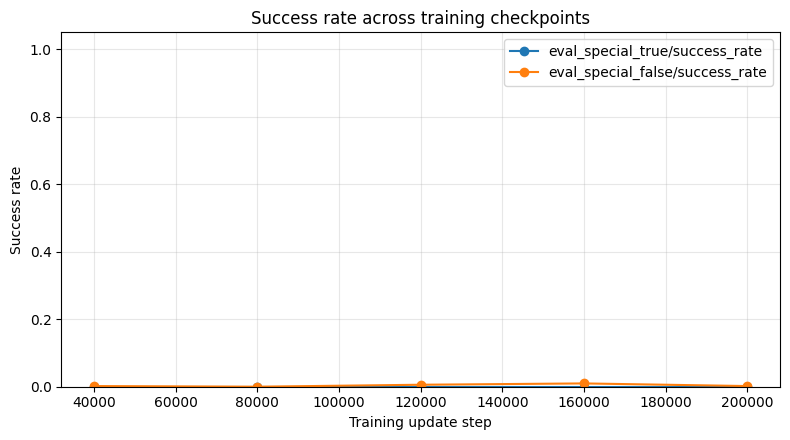

In [10]:
train_log_df = pd.DataFrame(train_logs)
train_log_df.insert(0, "step", np.arange(1, len(train_log_df) + 1))

print("Training logs (tail):")
display(train_log_df.tail(10))

print("Eval success-rate trajectory:")
display(eval_log_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    eval_log_df["step"],
    eval_log_df["eval_special_true/success_rate"],
    marker="o",
    label="eval_special_true/success_rate",
)
ax.plot(
    eval_log_df["step"],
    eval_log_df["eval_special_false/success_rate"],
    marker="o",
    label="eval_special_false/success_rate",
)
ax.set_title("Success rate across training checkpoints")
ax.set_xlabel("Training update step")
ax.set_ylabel("Success rate")
ax.set_ylim(0.0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Save the Trained Pipeline

Persist the fitted agent, logs, and any metadata needed to reproduce the run.

In [11]:
metadata = {
    "dataset_path": str(DATASET_PATH),
    "output_dir": str(OUTPUT_DIR),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_updates": NUM_UPDATES,
    "input_representation": INPUT_REPRESENTATION,
    "use_targets": USE_TARGETS,
    "discount": DISCOUNT,
    "value_p_curgoal": VALUE_P_CURGOAL,
    "value_p_trajgoal": VALUE_P_TRAJGOAL,
    "value_p_randomgoal": VALUE_P_RANDOMGOAL,
    "num_trajectories": len(trajectories),
    "num_transitions": int(cache["num_transitions"]),
}

np.savez(OUTPUT_DIR / "fast_offline_dqn_metadata.npz", **{k: np.asarray(v) if not isinstance(v, str) else v for k, v in metadata.items()})
pd.DataFrame(jax.device_get(train_logs)).to_csv(OUTPUT_DIR / "fast_offline_dqn_train_logs.csv", index=False)

checkpoint_path = save_agent(final_agent, config, str(OUTPUT_DIR), NUM_UPDATES)
print("Saved metadata and checkpoint to:", OUTPUT_DIR)
print("Checkpoint path:", checkpoint_path)
print("Metadata keys:", sorted(metadata.keys()))

Saved to /home/mbortkie/repos/golden-standard/runs/fast_offline_dqn_pipeline/params_200000.pkl
Saved metadata and checkpoint to: /home/mbortkie/repos/golden-standard/runs/fast_offline_dqn_pipeline
Checkpoint path: None
Metadata keys: ['batch_size', 'dataset_path', 'discount', 'input_representation', 'num_trajectories', 'num_transitions', 'num_updates', 'output_dir', 'seed', 'use_targets', 'value_p_curgoal', 'value_p_randomgoal', 'value_p_trajgoal']


## Run an End-to-End Example

Execute the whole path from cached raw data to a trained agent and an evaluation pass.

Demo batch observations shape: (16, 144)
Demo batch actions: [0 3 3 2 3 0 4 0]
Evaluation metrics:
{'eval_special_true/mean_reward': 0.0, 'eval_special_true/success_rate': 0.0, 'eval_special_false/mean_reward': 0.01171875, 'eval_special_false/success_rate': 0.01171875}


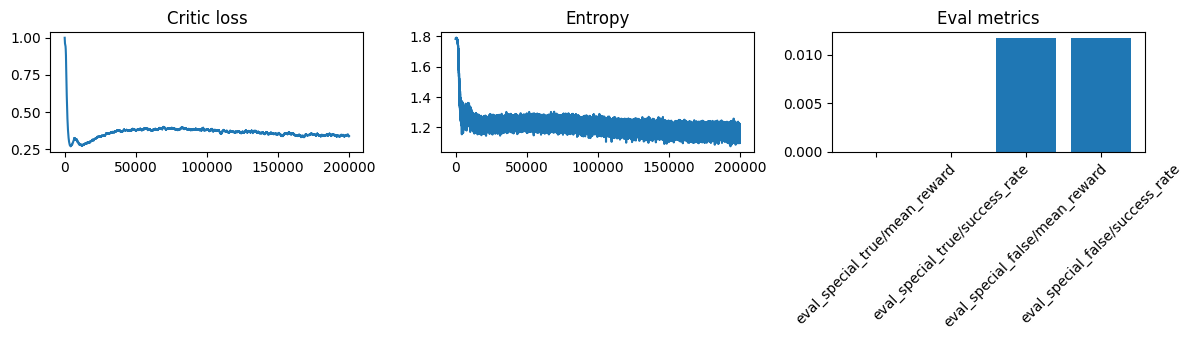

In [12]:
demo_batch = sample_batch_jax(
    jax.random.PRNGKey(SEED + 123),
    cache_jax,
    16,
    INPUT_REPRESENTATION,
    USE_TARGETS,
    value_p_curgoal=VALUE_P_CURGOAL,
    value_p_trajgoal=VALUE_P_TRAJGOAL,
    value_p_randomgoal=VALUE_P_RANDOMGOAL,
    discount=DISCOUNT,
)

metrics = evaluate_policy_both(final_agent, jax.random.PRNGKey(SEED + 456))
print("Demo batch observations shape:", demo_batch["observations"].shape)
print("Demo batch actions:", np.asarray(demo_batch["actions"])[:8])
print("Evaluation metrics:")
print(metrics)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(train_log_df["step"], train_log_df.get("critic/critic_loss", train_log_df.iloc[:, 1]))
axes[0].set_title("Critic loss")
axes[1].plot(train_log_df["step"], train_log_df.get("critic/entropy", train_log_df.iloc[:, 1]))
axes[1].set_title("Entropy")
axes[2].bar(list(metrics.keys()), list(metrics.values()))
axes[2].set_title("Eval metrics")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

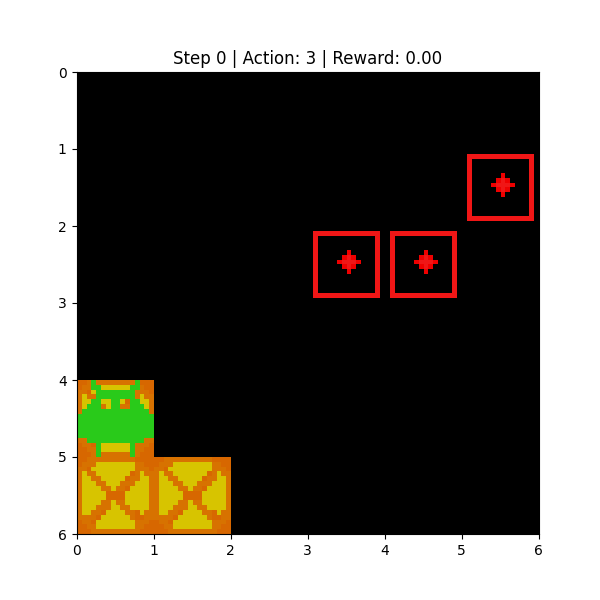

Saved rollout GIF to: /tmp/tmp7cf6tfz_.gif


In [13]:
from IPython.display import Image, display
import matplotlib.animation as animation
import tempfile

rollout_env = wrap_for_eval(create_env(config.env))
rollout_env.step = jax.jit(jax.vmap(rollout_env.step))
rollout_env.reset = jax.jit(jax.vmap(rollout_env.reset))

rollout_key = jax.random.PRNGKey(SEED + 12345)
_, _, timesteps = collect_data(
    final_agent,
    rollout_key,
    rollout_env,
    config.exp.num_envs,
    config.env.episode_length,
    use_targets=config.exp.use_targets,
    input_representation=config.exp.input_representation,
)

timesteps = jax.tree_util.tree_map(lambda x: x.swapaxes(1, 0), timesteps)
completed = jnp.where((timesteps.done | timesteps.truncated).any(axis=1), size=1, fill_value=0)[0]
rollout_index = int(completed[0])
rollout_timesteps = jax.tree_util.tree_map(lambda x: x[rollout_index : rollout_index + 1], timesteps)

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))
anim = animation.FuncAnimation(
    fig_gif,
    lambda frame: rollout_env._env.animate(
        ax_gif,
        rollout_timesteps,
        frame,
        img_prefix=str(REPO_ROOT / "assets"),
    ),
    frames=config.env.episode_length,
    interval=80,
    repeat=False,
)

gif_path = tempfile.NamedTemporaryFile(suffix=".gif", delete=False).name
anim.save(gif_path, writer="pillow")
plt.close(fig_gif)

display(Image(filename=gif_path))
print("Saved rollout GIF to:", gif_path)

,rollout_step,q_var_action_mean,q_var_action_std,q_var_action_sem,q_var_norm_action_mean,q_var_norm_action_std,q_var_norm_action_sem,q_var_global,q_mean,q_abs_mean,n_envs,setup
0,0,2.331580e-10,3.286204e-09,1.452311e-10,0.245480,0.440886,0.019485,5.155674e-10,0.000003,0.000003,512,generator_special=True
1,1,1.195242e-10,9.713997e-10,4.293021e-11,0.272007,0.557951,0.024658,2.403462e-10,0.000003,0.000003,512,generator_special=True
2,2,7.922060e-11,5.610484e-10,2.479507e-11,0.262303,0.506933,0.022403,1.541058e-10,0.000002,0.000002,512,generator_special=True
3,3,1.294270e-10,1.280344e-09,5.658377e-11,0.275915,0.551380,0.024368,2.808260e-10,0.000003,0.000003,512,generator_special=True
4,4,1.397806e-10,1.309518e-09,5.787308e-11,0.289930,0.599139,0.026478,2.803240e-10,0.000003,0.000003,512,generator_special=True
...,...,...,...,...,...,...,...,...,...,...,...,...
195,95,3.729203e-03,2.786966e-02,1.231676e-03,2.108590,1.470950,0.065007,1.200578e-02,0.018192,0.018192,512,generator_special=False
196,96,4.215554e-03,3.553597e-02,1.570483e-03,2.113993,1.473884,0.065137,1.292771e-02,0.018132,0.018132,512,generator_special=False
197,97,4.981502e-03,4.990882e-02,2.205679e-03,2.103630,1.475112,0.065191,1.554910e-02,0.018876,0.018876,512,generator_special=False
198,98,4.542780e-03,4.492564e-02,1.985452e-03,2.107480,1.477426,0.065294,1.429227e-02,0.018259,0.018259,512,generator_special=False


Rollout-start similarity summary (trained agent):
Mean absolute difference in action-wise Q variance: 0.002655
Mean absolute difference in normalized action-wise Q variance: 1.833141
Analysis envs per setup: 512


setup,rollout_step,generator_special=False,generator_special=True,abs_diff,abs_diff_sem
0,0,0.000002,2.331580e-10,0.000002,2.929001e-07
1,1,0.000003,1.195242e-10,0.000003,5.050654e-07
2,2,0.000007,7.922060e-11,0.000007,1.973675e-06
3,3,0.000033,1.294270e-10,0.000033,1.189295e-05
4,4,0.000041,1.397806e-10,0.000041,1.326897e-05
...,...,...,...,...,...
95,95,0.003729,1.989597e-06,0.003727,1.231678e-03
96,96,0.004216,1.752718e-06,0.004214,1.570484e-03
97,97,0.004982,1.998132e-06,0.004980,2.205680e-03
98,98,0.004543,1.755087e-06,0.004541,1.985452e-03


setup,rollout_step,generator_special=False,generator_special=True,abs_diff,abs_diff_sem
0,0,3.056666,0.245480,2.811187,0.042567
1,1,2.907671,0.272007,2.635664,0.048154
2,2,2.876954,0.262303,2.614651,0.048194
3,3,2.795839,0.275915,2.519925,0.051458
4,4,2.704429,0.289930,2.414499,0.056202
...,...,...,...,...,...
95,95,2.108590,0.508531,1.600059,0.075678
96,96,2.113993,0.503765,1.610228,0.075554
97,97,2.103630,0.511653,1.591977,0.075940
98,98,2.107480,0.507292,1.600187,0.075706


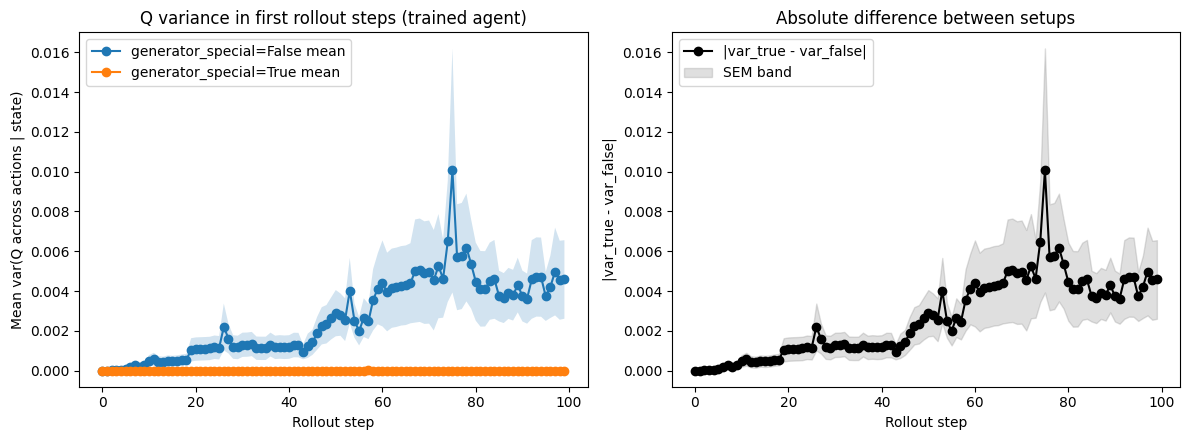

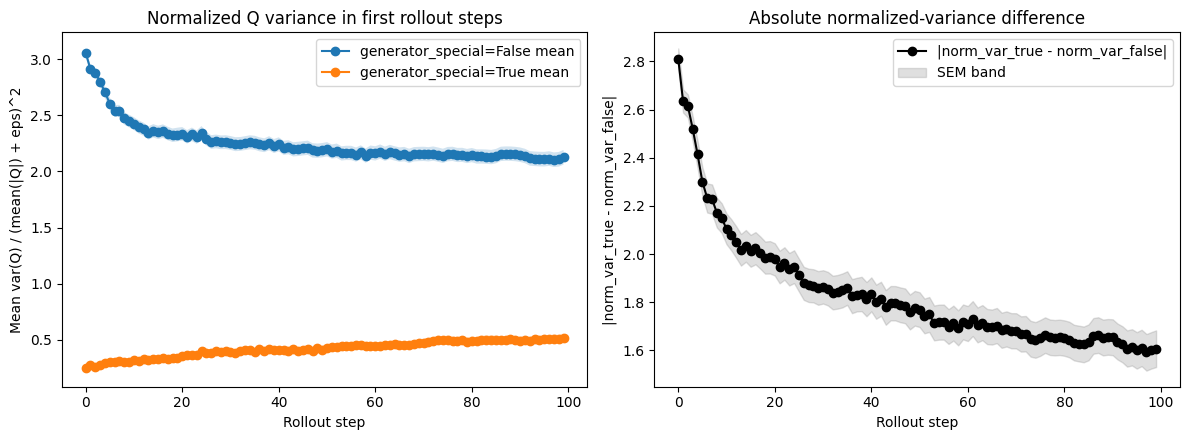

In [14]:
# Q-variance across first rollout steps (trained agent) for generator_special=True vs False
ROLLOUT_STEPS_TO_ANALYZE = 100
ROLLOUT_ANALYSIS_ENVS = 512
NORM_EPS = 1e-6

if "final_agent" not in globals():
    raise RuntimeError("final_agent is not available. Run the training cell first to create a trained agent.")

def get_q_values_from_grid(agent, grid_batch, goal_batch):
    if not USE_TARGETS:
        grid_batch = remove_targets(grid_batch)
        goal_batch = remove_targets(goal_batch)

    obs_enc = encode_grid_inputs(grid_batch, INPUT_REPRESENTATION)
    goal_enc = encode_grid_inputs(goal_batch, INPUT_REPRESENTATION)

    all_actions = jnp.tile(jnp.arange(6), (obs_enc.shape[0], 1))
    qs = jax.vmap(agent.network.select("critic"), in_axes=(None, None, 1))(obs_enc, goal_enc, all_actions)  # 6 x 2 x B
    if qs.ndim == 2:
        qs = qs[:, None, :]  # 6 x 1 x B fallback
    qs = qs.mean(axis=1).transpose(1, 0)  # B x 6
    return qs

def rollout_step_q_variance(agent, env_instance, key, rollout_steps, num_envs):
    _, _, timesteps = collect_data(
        agent,
        key,
        env_instance,
        num_envs,
        rollout_steps,
        use_targets=config.exp.use_targets,
        input_representation=config.exp.input_representation,
    )

    rows = []
    for step in range(rollout_steps):
        step_grid = timesteps.grid[step]
        step_goal = timesteps.goal[step]
        qs = get_q_values_from_grid(agent, step_grid, step_goal)  # [N, A]

        per_env_action_var = jnp.var(qs, axis=-1)  # [N]
        per_env_q_abs_mean = jnp.mean(jnp.abs(qs), axis=-1)  # [N]
        per_env_norm_action_var = per_env_action_var / jnp.square(per_env_q_abs_mean + NORM_EPS)
        n_env = int(per_env_action_var.shape[0])

        q_var_action_mean = float(jax.device_get(per_env_action_var.mean()))
        q_var_action_std = float(jax.device_get(per_env_action_var.std()))
        q_var_action_sem = float(q_var_action_std / np.sqrt(max(n_env, 1)))

        q_var_norm_action_mean = float(jax.device_get(per_env_norm_action_var.mean()))
        q_var_norm_action_std = float(jax.device_get(per_env_norm_action_var.std()))
        q_var_norm_action_sem = float(q_var_norm_action_std / np.sqrt(max(n_env, 1)))

        rows.append(
            {
                "rollout_step": step,
                "q_var_action_mean": q_var_action_mean,
                "q_var_action_std": q_var_action_std,
                "q_var_action_sem": q_var_action_sem,
                "q_var_norm_action_mean": q_var_norm_action_mean,
                "q_var_norm_action_std": q_var_norm_action_std,
                "q_var_norm_action_sem": q_var_norm_action_sem,
                "q_var_global": float(jax.device_get(jnp.var(qs))),
                "q_mean": float(jax.device_get(jnp.mean(qs))),
                "q_abs_mean": float(jax.device_get(jnp.mean(jnp.abs(qs)))),
                "n_envs": n_env,
            }
        )

    return pd.DataFrame(rows)

rollout_steps = min(ROLLOUT_STEPS_TO_ANALYZE, config.env.episode_length)
analysis_key = jax.random.PRNGKey(SEED + 40_000)
key_true, key_false = jax.random.split(analysis_key)

df_true = rollout_step_q_variance(
    final_agent,
    eval_env_special_true,
    key_true,
    rollout_steps,
    num_envs=ROLLOUT_ANALYSIS_ENVS,
 )
df_true["setup"] = "generator_special=True"

df_false = rollout_step_q_variance(
    final_agent,
    eval_env_special_false,
    key_false,
    rollout_steps,
    num_envs=ROLLOUT_ANALYSIS_ENVS,
 )
df_false["setup"] = "generator_special=False"

qvar_rollout_df = pd.concat([df_true, df_false], ignore_index=True)
display(qvar_rollout_df)

pivot_mean = qvar_rollout_df.pivot(index="rollout_step", columns="setup", values="q_var_action_mean").reset_index()
pivot_sem = qvar_rollout_df.pivot(index="rollout_step", columns="setup", values="q_var_action_sem").reset_index()
pivot = pivot_mean.copy()
pivot["abs_diff"] = (pivot["generator_special=True"] - pivot["generator_special=False"]).abs()
pivot["abs_diff_sem"] = np.sqrt(
    np.square(pivot_sem["generator_special=True"]) + np.square(pivot_sem["generator_special=False"])
)

pivot_norm_mean = qvar_rollout_df.pivot(index="rollout_step", columns="setup", values="q_var_norm_action_mean").reset_index()
pivot_norm_sem = qvar_rollout_df.pivot(index="rollout_step", columns="setup", values="q_var_norm_action_sem").reset_index()
pivot_norm = pivot_norm_mean.copy()
pivot_norm["abs_diff"] = (pivot_norm["generator_special=True"] - pivot_norm["generator_special=False"]).abs()
pivot_norm["abs_diff_sem"] = np.sqrt(
    np.square(pivot_norm_sem["generator_special=True"]) + np.square(pivot_norm_sem["generator_special=False"])
)

print("Rollout-start similarity summary (trained agent):")
print(f"Mean absolute difference in action-wise Q variance: {pivot['abs_diff'].mean():.6f}")
print(f"Mean absolute difference in normalized action-wise Q variance: {pivot_norm['abs_diff'].mean():.6f}")
print("Analysis envs per setup:", ROLLOUT_ANALYSIS_ENVS)
display(pivot)
display(pivot_norm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for setup_name, setup_df in qvar_rollout_df.groupby("setup"):
    x = setup_df["rollout_step"].to_numpy()
    y = setup_df["q_var_action_mean"].to_numpy()
    yerr = setup_df["q_var_action_sem"].to_numpy()
    axes[0].plot(x, y, marker="o", label=f"{setup_name} mean")
    axes[0].fill_between(x, y - yerr, y + yerr, alpha=0.2)
axes[0].set_title("Q variance in first rollout steps (trained agent)")
axes[0].set_xlabel("Rollout step")
axes[0].set_ylabel("Mean var(Q across actions | state)")
axes[0].legend()

axes[1].plot(pivot["rollout_step"], pivot["abs_diff"], marker="o", color="black", label="|var_true - var_false|")
axes[1].fill_between(
    pivot["rollout_step"],
    pivot["abs_diff"] - pivot["abs_diff_sem"],
    pivot["abs_diff"] + pivot["abs_diff_sem"],
    color="gray",
    alpha=0.25,
    label="SEM band",
)
axes[1].set_title("Absolute difference between setups")
axes[1].set_xlabel("Rollout step")
axes[1].set_ylabel("|var_true - var_false|")
axes[1].legend()

plt.tight_layout()
plt.show()

fig_norm, axes_norm = plt.subplots(1, 2, figsize=(12, 4.5))

for setup_name, setup_df in qvar_rollout_df.groupby("setup"):
    x = setup_df["rollout_step"].to_numpy()
    y = setup_df["q_var_norm_action_mean"].to_numpy()
    yerr = setup_df["q_var_norm_action_sem"].to_numpy()
    axes_norm[0].plot(x, y, marker="o", label=f"{setup_name} mean")
    axes_norm[0].fill_between(x, y - yerr, y + yerr, alpha=0.2)
axes_norm[0].set_title("Normalized Q variance in first rollout steps")
axes_norm[0].set_xlabel("Rollout step")
axes_norm[0].set_ylabel("Mean var(Q) / (mean(|Q|) + eps)^2")
axes_norm[0].legend()

axes_norm[1].plot(
    pivot_norm["rollout_step"],
    pivot_norm["abs_diff"],
    marker="o",
    color="black",
    label="|norm_var_true - norm_var_false|",
)
axes_norm[1].fill_between(
    pivot_norm["rollout_step"],
    pivot_norm["abs_diff"] - pivot_norm["abs_diff_sem"],
    pivot_norm["abs_diff"] + pivot_norm["abs_diff_sem"],
    color="gray",
    alpha=0.25,
    label="SEM band",
)
axes_norm[1].set_title("Absolute normalized-variance difference")
axes_norm[1].set_xlabel("Rollout step")
axes_norm[1].set_ylabel("|norm_var_true - norm_var_false|")
axes_norm[1].legend()

plt.tight_layout()
plt.show()

,setup,step,mean_spearman_rho,std_spearman_rho,sem_spearman_rho,mean_best_action_agreement,std_best_action_agreement,sem_best_action_agreement,n_valid_envs,n_envs
0,eval_special_true,1,0.117251,0.407148,0.017994,0.154297,0.361233,0.015964,512,512
1,eval_special_true,2,0.120947,0.400122,0.017683,0.136719,0.343550,0.015183,512,512
2,eval_special_true,3,0.109151,0.384809,0.017124,0.134766,0.341473,0.015091,505,512
3,eval_special_true,4,0.115779,0.381347,0.016953,0.140625,0.347634,0.015363,506,512
4,eval_special_true,5,0.104626,0.389407,0.017397,0.146484,0.353591,0.015627,501,512
...,...,...,...,...,...,...,...,...,...,...
195,eval_special_false,96,0.115700,0.424416,0.018905,0.060547,0.238497,0.010540,504,512
196,eval_special_false,97,0.106314,0.426840,0.019013,0.058594,0.234863,0.010380,504,512
197,eval_special_false,98,0.104234,0.422523,0.018858,0.054688,0.227369,0.010048,502,512
198,eval_special_false,99,0.105506,0.420935,0.018806,0.054688,0.227369,0.010048,501,512


,setup,mean_of_step_means,sem_of_step_means,min_step_mean,max_step_mean,mean_best_action_agreement_over_rollout,sem_best_action_agreement_over_rollout,min_step_best_action_agreement,max_step_best_action_agreement,num_steps,num_envs_per_step
0,eval_special_false,0.156167,0.004418,0.094812,0.268961,0.065645,0.001416,0.015625,0.121094,100,512
1,eval_special_true,0.078525,0.001500,0.052384,0.120947,0.218418,0.002987,0.134766,0.259766,100,512


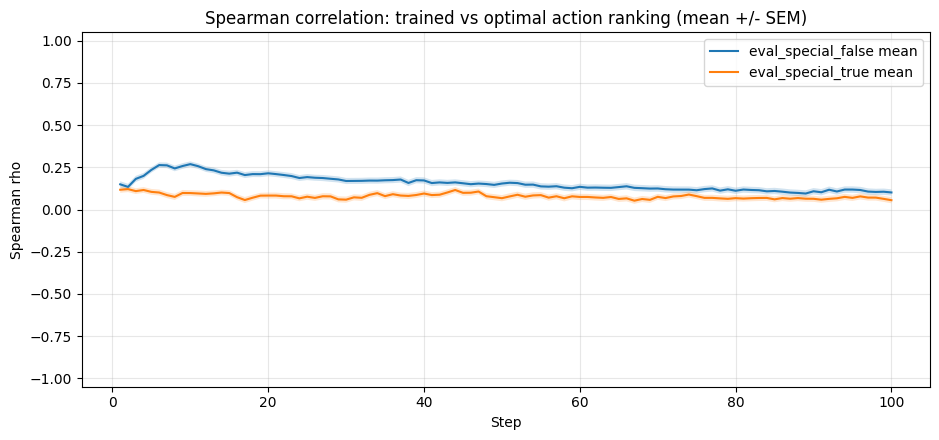

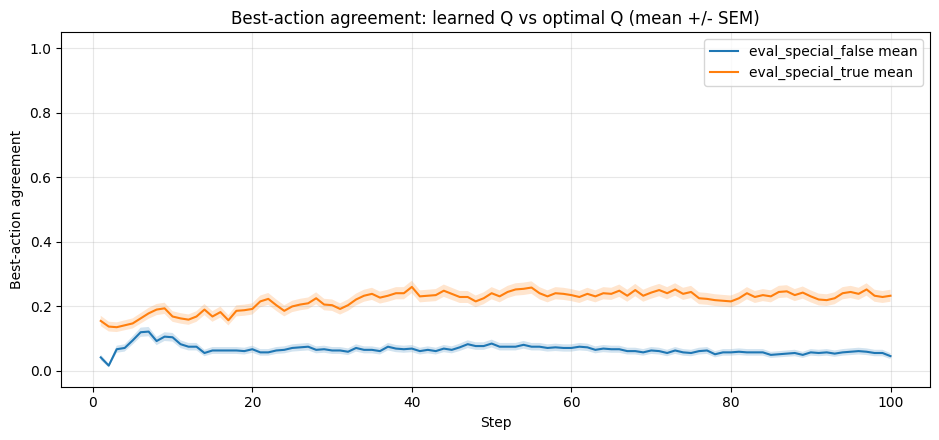

Compared parallel envs: 512
                setup  mean_best_action_agreement_over_rollout  \
0  eval_special_false                                 0.065645   
1   eval_special_true                                 0.218418   

   sem_best_action_agreement_over_rollout  
0                                0.001416  
1                                0.002987  


In [15]:
# Spearman correlation of action rankings: trained Q vs optimal Q across rollout steps
from functools import partial

if "final_agent" not in globals():
    raise RuntimeError("final_agent is not available. Run training cells first.")

try:
    from optimal_q import solve_state_vmapped
except ModuleNotFoundError:
    from src.optimal_q import solve_state_vmapped

ACTION_NAMES = {0: "UP", 1: "DOWN", 2: "LEFT", 3: "RIGHT", 4: "PICK_UP", 5: "PUT_DOWN"}
NUM_COMPARE_ENVS = 512


def repeat_state_for_actions(state, n_actions=6):
    return jax.tree_util.tree_map(
        lambda x: jnp.repeat(x, repeats=n_actions, axis=0),
        state,
    )


def make_batched_optimal_q_fn(env, discount, max_boxes, max_actions, max_move, rollout_steps=100, fallback_action=0):
    step_batch = jax.jit(jax.vmap(lambda st, act: env.step(st, act), in_axes=(0, 0)))

    @partial(
        jax.jit,
        static_argnames=("max_boxes", "max_actions", "max_move", "rollout_steps", "fallback_action"),
    )
    def _optimal_q_values_batched(
        states_batch,
        discount,
        *,
        max_boxes=16,
        max_actions=512,
        max_move=16,
        rollout_steps=100,
        fallback_action=0,
    ):
        planned_actions, action_counts = solve_state_vmapped(
            states_batch.grid,
            max_boxes=max_boxes,
            max_actions=max_actions,
            max_move=max_move,
        )

        batch_size = planned_actions.shape[0]
        q_acc = jnp.zeros((batch_size,), dtype=jnp.float32)
        disc_acc = jnp.ones((batch_size,), dtype=jnp.float32)

        def scan_step(carry, xs):
            current_states, q_values, disc = carry
            t, action_t = xs
            fallback_actions = jnp.full_like(action_t, jnp.int8(fallback_action))
            chosen_actions = jnp.where(t < action_counts, action_t, fallback_actions).astype(jnp.int32)

            next_states, rewards, _, _ = step_batch(current_states, chosen_actions)
            q_values = q_values + disc * rewards
            disc = disc * discount
            current_states = next_states
            return (current_states, q_values, disc), None

        xs = (jnp.arange(rollout_steps, dtype=jnp.int32), planned_actions.T[:rollout_steps])
        (_, q_values, _), _ = jax.lax.scan(scan_step, (states_batch, q_acc, disc_acc), xs)
        return q_values, action_counts

    def run(states_batch):
        return _optimal_q_values_batched(
            states_batch,
            discount,
            max_boxes=max_boxes,
            max_actions=max_actions,
            max_move=max_move,
            rollout_steps=rollout_steps,
            fallback_action=fallback_action,
        )

    return run


def trained_q_for_states(states_batch):
    grid_batch = states_batch.grid
    goal_batch = states_batch.goal
    if not USE_TARGETS:
        grid_batch = remove_targets(grid_batch)
        goal_batch = remove_targets(goal_batch)

    obs_enc = encode_grid_inputs(grid_batch, INPUT_REPRESENTATION)
    goal_enc = encode_grid_inputs(goal_batch, INPUT_REPRESENTATION)
    all_actions = jnp.tile(jnp.arange(6, dtype=jnp.int32), (obs_enc.shape[0], 1))

    q_raw = jax.vmap(final_agent.network.select("critic"), in_axes=(None, None, 1))(obs_enc, goal_enc, all_actions)
    if q_raw.ndim == 2:
        q_raw = q_raw[:, None, :]
    return np.asarray(q_raw.mean(axis=1).transpose(1, 0), dtype=np.float32)  # [N, 6]


def spearman_batch_from_scores(scores_a: np.ndarray, scores_b: np.ndarray) -> np.ndarray:
    # scores_a, scores_b: [N, A]
    n = scores_a.shape[0]
    rhos = np.empty((n,), dtype=np.float32)
    for i in range(n):
        rank_a = pd.Series(scores_a[i]).rank(method="average", ascending=False).to_numpy(dtype=np.float32)
        rank_b = pd.Series(scores_b[i]).rank(method="average", ascending=False).to_numpy(dtype=np.float32)
        if np.isclose(np.std(rank_a), 0.0) or np.isclose(np.std(rank_b), 0.0):
            rhos[i] = np.nan
        else:
            rhos[i] = np.corrcoef(rank_a, rank_b)[0, 1]
    return rhos


def best_action_agreement_batch(scores_a: np.ndarray, scores_b: np.ndarray) -> np.ndarray:
    # Tie-aware top-action agreement: success if any best action overlaps between learned and optimal.
    best_a = np.isclose(scores_a, scores_a.max(axis=1, keepdims=True), rtol=1e-6, atol=1e-8)
    best_b = np.isclose(scores_b, scores_b.max(axis=1, keepdims=True), rtol=1e-6, atol=1e-8)
    agreement = np.logical_and(best_a, best_b).any(axis=1)
    return agreement.astype(np.float32)


def compare_setup(setup_name: str, eval_env_instance, generator_special: bool, seed_offset: int):
    key = jax.random.PRNGKey(SEED + seed_offset)
    _, _, timesteps = collect_data(
        final_agent,
        key,
        eval_env_instance,
        NUM_COMPARE_ENVS,
        config.env.episode_length,
        use_targets=config.exp.use_targets,
        input_representation=config.exp.input_representation,
    )
    timesteps = jax.tree_util.tree_map(lambda x: x.swapaxes(1, 0), timesteps)  # [N, T, ...]

    cmp_env = BoxMovingEnv(
        grid_size=config.env.grid_size,
        episode_length=config.env.episode_length,
        number_of_boxes_min=config.env.number_of_boxes_min,
        number_of_boxes_max=config.env.number_of_boxes_max,
        number_of_moving_boxes_max=config.env.number_of_moving_boxes_max,
        terminate_when_success=False,
        level_generator=config.env.level_generator,
        quarter_size=config.env.quarter_size,
        generator_special=generator_special,
    )

    step_batch = jax.jit(jax.vmap(lambda st, act: cmp_env.step(st, act), in_axes=(0, 0)))
    optimal_tail_fn = make_batched_optimal_q_fn(
        env=cmp_env,
        discount=DISCOUNT,
        max_boxes=max(config.env.number_of_boxes_max + 2, 8),
        max_actions=max(config.env.episode_length, 100),
        max_move=config.env.grid_size,
        rollout_steps=100,
        fallback_action=0,
    )

    step_rows = []
    for step in range(config.env.episode_length):
        states_t = jax.tree_util.tree_map(lambda x: x[:, step], timesteps)  # [N, ...]

        trained_q = trained_q_for_states(states_t)  # [N, 6]

        n_envs = trained_q.shape[0]
        candidate_actions = jnp.tile(jnp.arange(6, dtype=jnp.int32), (n_envs,))  # [N*6]
        repeated_states = repeat_state_for_actions(states_t, n_actions=6)  # [N*6, ...]
        next_states, immediate_rewards, _, _ = step_batch(repeated_states, candidate_actions)

        tail_q, _ = optimal_tail_fn(next_states)
        optimal_q = np.asarray(immediate_rewards + DISCOUNT * tail_q, dtype=np.float32).reshape(n_envs, 6)

        rho_vec = spearman_batch_from_scores(trained_q, optimal_q)
        valid = np.isfinite(rho_vec)
        valid_count = int(valid.sum())
        mean_rho = float(np.nanmean(rho_vec)) if valid_count > 0 else np.nan
        std_rho = float(np.nanstd(rho_vec)) if valid_count > 0 else np.nan
        sem_rho = float(std_rho / np.sqrt(valid_count)) if valid_count > 0 else np.nan

        best_action_agreement = best_action_agreement_batch(trained_q, optimal_q)
        mean_best_action_agreement = float(np.mean(best_action_agreement)) if n_envs > 0 else np.nan
        std_best_action_agreement = float(np.std(best_action_agreement)) if n_envs > 0 else np.nan
        sem_best_action_agreement = float(std_best_action_agreement / np.sqrt(max(n_envs, 1))) if n_envs > 0 else np.nan

        step_rows.append(
            {
                "setup": setup_name,
                "step": step + 1,
                "mean_spearman_rho": mean_rho,
                "std_spearman_rho": std_rho,
                "sem_spearman_rho": sem_rho,
                "mean_best_action_agreement": mean_best_action_agreement,
                "std_best_action_agreement": std_best_action_agreement,
                "sem_best_action_agreement": sem_best_action_agreement,
                "n_valid_envs": valid_count,
                "n_envs": n_envs,
            }
        )

    return pd.DataFrame(step_rows)


df_true = compare_setup(
    setup_name="eval_special_true",
    eval_env_instance=eval_env_special_true,
    generator_special=True,
    seed_offset=70_000,
 )
df_false = compare_setup(
    setup_name="eval_special_false",
    eval_env_instance=eval_env_special_false,
    generator_special=False,
    seed_offset=80_000,
 )

spearman_step_df = pd.concat([df_true, df_false], ignore_index=True)

summary_rows = []
for setup_name, group_df in spearman_step_df.groupby("setup"):
    valid_mask = np.isfinite(group_df["mean_spearman_rho"].to_numpy())
    rho_values = group_df.loc[valid_mask, "mean_spearman_rho"].to_numpy(dtype=np.float32)
    agree_values = group_df["mean_best_action_agreement"].to_numpy(dtype=np.float32)

    n_rho = rho_values.shape[0]
    n_agree = agree_values.shape[0]

    summary_rows.append(
        {
            "setup": setup_name,
            "mean_of_step_means": float(np.mean(rho_values)) if n_rho > 0 else np.nan,
            "sem_of_step_means": float(np.std(rho_values) / np.sqrt(n_rho)) if n_rho > 0 else np.nan,
            "min_step_mean": float(np.min(rho_values)) if n_rho > 0 else np.nan,
            "max_step_mean": float(np.max(rho_values)) if n_rho > 0 else np.nan,
            "mean_best_action_agreement_over_rollout": float(np.mean(agree_values)) if n_agree > 0 else np.nan,
            "sem_best_action_agreement_over_rollout": float(np.std(agree_values) / np.sqrt(n_agree)) if n_agree > 0 else np.nan,
            "min_step_best_action_agreement": float(np.min(agree_values)) if n_agree > 0 else np.nan,
            "max_step_best_action_agreement": float(np.max(agree_values)) if n_agree > 0 else np.nan,
            "num_steps": int(n_rho),
            "num_envs_per_step": NUM_COMPARE_ENVS,
        }
    )
summary_df = pd.DataFrame(summary_rows)

display(spearman_step_df)
display(summary_df)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
for setup_name, group_df in spearman_step_df.groupby("setup"):
    x = group_df["step"].to_numpy()
    y = group_df["mean_spearman_rho"].to_numpy(dtype=np.float32)
    yerr = group_df["sem_spearman_rho"].to_numpy(dtype=np.float32)
    ax.plot(x, y, label=f"{setup_name} mean")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.2)

ax.set_title("Spearman correlation: trained vs optimal action ranking (mean +/- SEM)")
ax.set_xlabel("Step")
ax.set_ylabel("Spearman rho")
ax.set_ylim(-1.05, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig_agree, ax_agree = plt.subplots(figsize=(9.5, 4.5))
for setup_name, group_df in spearman_step_df.groupby("setup"):
    x = group_df["step"].to_numpy()
    y = group_df["mean_best_action_agreement"].to_numpy(dtype=np.float32)
    yerr = group_df["sem_best_action_agreement"].to_numpy(dtype=np.float32)
    ax_agree.plot(x, y, label=f"{setup_name} mean")
    ax_agree.fill_between(x, y - yerr, y + yerr, alpha=0.2)

ax_agree.set_title("Best-action agreement: learned Q vs optimal Q (mean +/- SEM)")
ax_agree.set_xlabel("Step")
ax_agree.set_ylabel("Best-action agreement")
ax_agree.set_ylim(-0.05, 1.05)
ax_agree.grid(alpha=0.3)
ax_agree.legend()
plt.tight_layout()
plt.show()

print("Compared parallel envs:", NUM_COMPARE_ENVS)
print(summary_df[["setup", "mean_best_action_agreement_over_rollout", "sem_best_action_agreement_over_rollout"]])